# Option 1 — Robot Motion Forecasting and Anomaly Detection (RoboAI UR5e)

**Research question:** *Can a model trained only on normal demonstrations predict how the UR5e will move, and use its prediction errors to detect abnormal behaviour (collisions, freezes, drift, sensor noise)?*

**Idea in one picture:**

```
past 10 robot states ──► forecasting model ──► predicted next 10 states
                                                     │
                          actual next states ────────┤  compare
                                                     ▼
                                   large error  ⇒  anomaly score ↑
```

| Part | What happens |
|---|---|
| 1 | Extract the robot-state numbers from the dataset into one small file (~5 MB); images are skipped |
| 2 | Clean the data (fix quaternion sign flips), split episodes into train / validation / test |
| 3 | Train forecasters: 3 simple baselines + MLP + GRU |
| 4 | Evaluate forecasting accuracy (per horizon, in millimetres for the hand position) |
| 5 | Inject synthetic anomalies (jerk, freeze, drift, noise) into test episodes |
| 6 | Detect them with forecast-error scores; compare detectors (AUC, detection rate, delay) |
| 7 | Sensitivity: how small an anomaly can still be detected? |
| 8 | Look for *real* unusual episodes in the recordings |
| 9 | Summary and how to grow this into a thesis |

**Resources:** only numbers (≈58k time steps × 15 values). Runs on a laptop CPU in a few minutes; a GPU is used automatically if available.

## 0 — Setup

In [1]:
import os, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", DEVICE)

DATASET_PATH = r"C:\Users\Nahid\Test\dataset"                     # only needed once, for Part 1
PROCESSED_PATH = r"C:\Users\Nahid\Test\processed\robot_motion.npz"
RESULTS_DIR = r"C:\Users\Nahid\Test\results"

SEED = 0
K = 10   # past steps the model sees
H = 10   # future steps it predicts

np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)
pd.set_option("display.precision", 3)

PyTorch 2.5.1+cu121 | device: cuda


## 1 — Extract the robot states into a small file (runs once)

Only `observation/robot_state` (15 numbers), `action` (7 numbers) and the instruction are read; image decoding is skipped, so this takes well under a minute. Afterwards the 24 GB dataset is no longer needed: this notebook works from `processed/robot_motion.npz` alone (e.g. on a laptop or in Colab).

In [2]:
if os.path.exists(PROCESSED_PATH):
    print("Using existing file:", PROCESSED_PATH)
else:
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")
    import tensorflow_datasets as tfds

    builder = tfds.builder_from_directory(DATASET_PATH)
    split_info = builder.info.splits["train"]
    available = 0   # works with a partial download: use the episodes in the first contiguous shards
    for i, n in enumerate(split_info.shard_lengths):
        shard = f"{builder.info.name}-train.tfrecord-{i:05d}-of-{split_info.num_shards:05d}"
        if not os.path.exists(os.path.join(DATASET_PATH, shard)):
            break
        available += n
    split = "train" if available == split_info.num_examples else f"train[:{available}]"

    decoders = {"steps": {"observation": {"image": tfds.decode.SkipDecoding()}}}
    states, actions, lengths, instructions, file_names = [], [], [], [], []
    t0 = time.time()
    for ep in builder.as_dataset(split=split, decoders=decoders):
        steps = ep["steps"].map(lambda s: (s["observation"]["robot_state"], s["action"], s["language_instruction"]))
        s_ep, a_ep, instr = [], [], b""
        for s, a, text in steps:
            s_ep.append(s.numpy()); a_ep.append(a.numpy()); instr = text.numpy()
        states.append(np.stack(s_ep)); actions.append(np.stack(a_ep)); lengths.append(len(s_ep))
        instructions.append(instr.decode("utf-8")); file_names.append(ep["episode_metadata"]["file_name"].numpy().decode("utf-8"))

    os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
    np.savez_compressed(PROCESSED_PATH, states=np.concatenate(states).astype(np.float32),
                        actions=np.concatenate(actions).astype(np.float32), lengths=np.array(lengths),
                        instructions=np.array(instructions), file_names=np.array(file_names))
    print(f"Extracted {len(lengths)} episodes in {time.time() - t0:.0f}s")

print(f"File size: {os.path.getsize(PROCESSED_PATH) / 1e6:.1f} MB")

Extracted 443 episodes in 16s
File size: 4.0 MB


## 2 — Load, clean and split

**What the 15 state values are** (inferred from their ranges and behaviour — confirm with the dataset authors for the thesis):

| index | name | meaning |
|---|---|---|
| 0–5 | `joint0`…`joint5` | UR5e joint angles [rad] |
| 6–8 | `x`, `y`, `z` | tool (hand) position [m] |
| 9–12 | `q0`…`q3` | tool orientation as a unit quaternion |
| 13 | `gripper` | 0 = open, 1 = closed |
| 14 | `s14` | always 0 → dropped |

**Cleaning — quaternion sign flips.** A quaternion *q* and *−q* describe the same orientation, and the recording sometimes switches between them (359 times). To a model this looks like a sudden jump of size 2, i.e. a fake anomaly. The fix is standard: flip the sign whenever the new quaternion points away from the previous one.

**Split by episode** (70 % train / 15 % validation / 15 % test): a model must never see any part of a test episode during training.

In [3]:
data = np.load(PROCESSED_PATH)
lengths = data["lengths"]
offsets = np.concatenate([[0], np.cumsum(lengths)])
instructions = data["instructions"]
file_names = data["file_names"]
ALL_NAMES = [f"joint{i}" for i in range(6)] + ["x", "y", "z", "q0", "q1", "q2", "q3", "gripper", "s14"]
raw = [data["states"][offsets[i]:offsets[i + 1]] for i in range(len(lengths))]
print(f"{len(raw)} episodes, {offsets[-1]} steps, lengths {lengths.min()}–{lengths.max()} (mean {lengths.mean():.0f})")

def fix_quaternion_signs(s, q=slice(9, 13)):
    s = s.copy()
    for t in range(1, len(s)):
        if np.dot(s[t, q], s[t - 1, q]) < 0:
            s[t, q] *= -1
    return s

flips = sum(int((np.einsum("ij,ij->i", s[1:, 9:13], s[:-1, 9:13]) < 0).sum()) for s in raw)
episodes = [fix_quaternion_signs(s) for s in raw]
print(f"Quaternion sign flips fixed: {flips}")

keep = np.concatenate(episodes).std(0) > 1e-6          # drop constant columns
NAMES = [n for n, k in zip(ALL_NAMES, keep) if k]
episodes = [s[:, keep] for s in episodes]
D = len(NAMES)
GRIPPER = NAMES.index("gripper")
XYZ = [NAMES.index(n) for n in ("x", "y", "z")]
CONT_DIMS = [i for i in range(D) if i != GRIPPER]       # continuous dims used for anomaly scores
print(f"Using {D} state dims: {NAMES}")

rng = np.random.default_rng(SEED)
order = rng.permutation(len(episodes))
n_val, n_test = int(0.15 * len(order)), int(0.15 * len(order))
VAL, TEST, TRAIN = order[:n_val], order[n_val:n_val + n_test], order[n_val + n_test:]
print(f"episodes: train {len(TRAIN)} | val {len(VAL)} | test {len(TEST)}")

# normalize with training statistics only
train_all = np.concatenate([episodes[i] for i in TRAIN])
MU, SD = train_all.mean(0), train_all.std(0)
z_eps = [(s - MU) / SD for s in episodes]
STEP_SD = np.concatenate([np.diff(z_eps[i], axis=0) for i in TRAIN]).std(0)   # typical per-step change

443 episodes, 57742 steps, lengths 82–349 (mean 130)
Quaternion sign flips fixed: 359
Using 14 state dims: ['joint0', 'joint1', 'joint2', 'joint3', 'joint4', 'joint5', 'x', 'y', 'z', 'q0', 'q1', 'q2', 'q3', 'gripper']
episodes: train 311 | val 66 | test 66


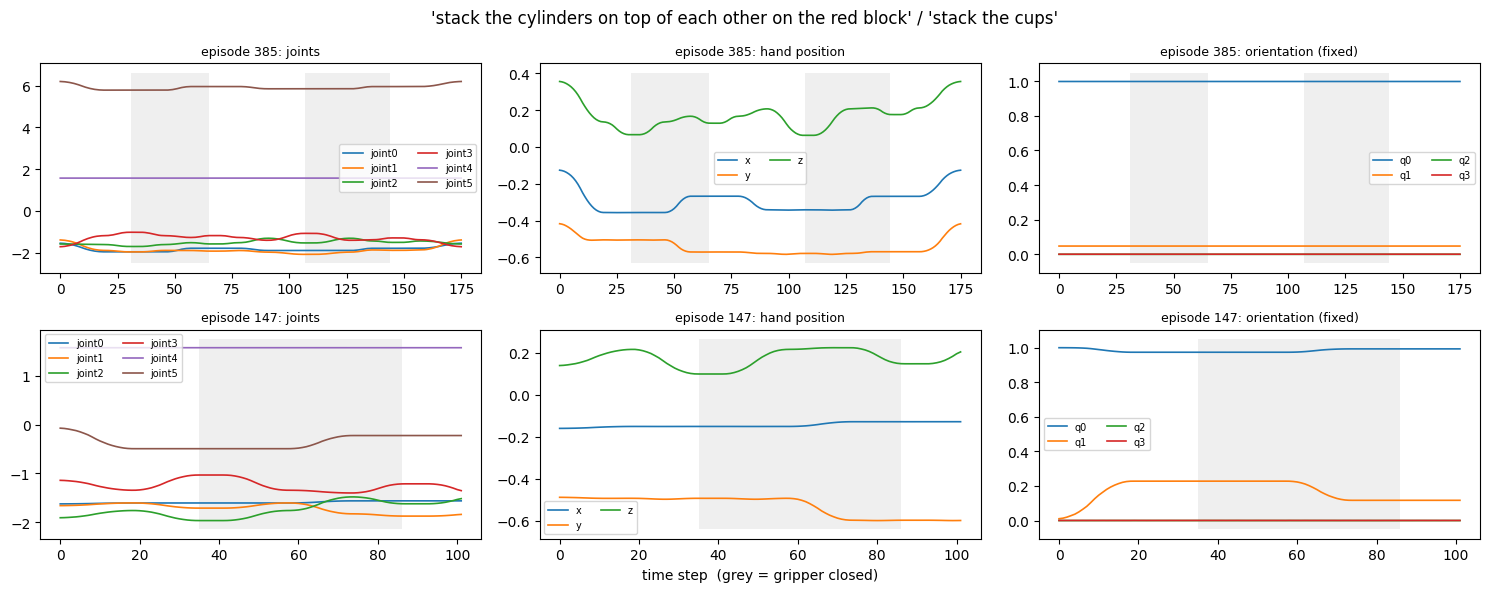

In [4]:
# Look at a few training episodes
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
groups = [("joints", [n for n in NAMES if n.startswith("joint")]), ("hand position", ["x", "y", "z"]),
          ("orientation (fixed)", ["q0", "q1", "q2", "q3"]), ("gripper", ["gripper"])]
ep_show = TRAIN[:2]
for row, i in enumerate(ep_show):
    for col, (title, names) in enumerate(groups[:3]):
        ax = axes[row, col]
        for n in names:
            if n in NAMES:
                ax.plot(episodes[i][:, NAMES.index(n)], label=n, lw=1.2)
        g = episodes[i][:, GRIPPER]
        ax.fill_between(range(len(g)), *ax.get_ylim(), where=g > 0.5, color="grey", alpha=0.12, lw=0)
        ax.set_title(f"episode {i}: {title}", fontsize=9); ax.legend(fontsize=7, ncol=2)
axes[1, 1].set_xlabel("time step  (grey = gripper closed)")
fig.suptitle(f"'{instructions[ep_show[0]]}' / '{instructions[ep_show[1]]}'")
plt.tight_layout(); plt.show()

## 3 — Forecasting models

Every model sees the last `K` = 10 states and predicts the **change** of each state value over the next `H` = 10 steps (relative to the last seen state).

| Model | Type | Why it is included |
|---|---|---|
| zero-change | baseline | "the robot stays where it is" |
| constant velocity | baseline | "the robot keeps moving as in the last step" (physics prior) |
| ridge regression | linear | best *linear* model — shows whether a neural network is needed at all |
| MLP | neural | non-linear, sees the window as a flat vector |
| GRU | neural (recurrent) | processes the window as a sequence |

Neural models are trained with early stopping on the validation episodes.

In [5]:
def make_windows(idx):
    """Past windows X (N, K, D) and future changes Y (N, H, D) from the episodes in idx."""
    X, Y = [], []
    for i in idx:
        z = z_eps[i]
        if len(z) < K + H:
            continue
        w = sliding_window_view(z, K + H, axis=0).transpose(0, 2, 1)
        X.append(w[:, :K]); Y.append(w[:, K:] - w[:, K - 1:K])
    return np.concatenate(X).astype(np.float32), np.concatenate(Y).astype(np.float32)

Xtr, Ytr = make_windows(TRAIN)
Xva, Yva = make_windows(VAL)
Xte, Yte = make_windows(TEST)
Y_SD = Ytr.reshape(len(Ytr), -1).std(0).reshape(H, D) + 1e-6   # target scaling per (horizon, dim)
print(f"windows: train {len(Xtr)} | val {len(Xva)} | test {len(Xte)}")

# ---- baselines -------------------------------------------------------------
def predict_zero(X):
    return np.zeros((len(X), H, D), np.float32)

def predict_const_vel(X):
    v = X[:, -1] - X[:, -2]
    return (np.arange(1, H + 1)[None, :, None] * v[:, None, :]).astype(np.float32)

def ridge_features(X):
    vel = np.diff(X, axis=1)
    return np.concatenate([X.reshape(len(X), -1), vel.reshape(len(X), -1), np.ones((len(X), 1), np.float32)], 1)

def fit_ridge(X, Y, lam=1.0):
    F = ridge_features(X).astype(np.float64)
    T = (Y / Y_SD).reshape(len(Y), -1).astype(np.float64)
    W = np.linalg.solve(F.T @ F + lam * np.eye(F.shape[1]), F.T @ T)
    return lambda Xn: ((ridge_features(Xn) @ W).reshape(len(Xn), H, D) * Y_SD).astype(np.float32)

t0 = time.time()
predict_ridge = fit_ridge(Xtr, Ytr)
print(f"ridge fitted in {time.time() - t0:.1f}s")

windows: train 34227 | val 7906 | test 7192
ridge fitted in 0.1s


MLP trained in 2s (24 epochs)


GRU trained in 4s (34 epochs)


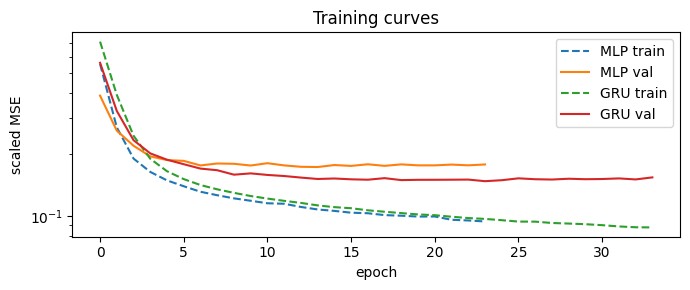

In [6]:
# ---- neural forecasters ----------------------------------------------------
def with_velocity(x):
    return torch.cat([x, torch.diff(x, dim=1, prepend=x[:, :1])], dim=-1)

class MLPForecaster(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(K * 2 * D, hidden), nn.GELU(),
                                 nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, H * D))
    def forward(self, x):
        return self.net(with_velocity(x)).view(-1, H, D)

class GRUForecaster(nn.Module):
    def __init__(self, hidden=128, layers=2):
        super().__init__()
        self.gru = nn.GRU(2 * D, hidden, layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden, H * D)
    def forward(self, x):
        out, _ = self.gru(with_velocity(x))
        return self.head(out[:, -1]).view(-1, H, D)

Y_SD_T = torch.tensor(Y_SD, device=DEVICE)

def train_forecaster(model, epochs=80, batch=512, lr=2e-3, patience=10):
    torch.manual_seed(SEED)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    Xt, Yt = torch.tensor(Xtr, device=DEVICE), torch.tensor(Ytr, device=DEVICE) / Y_SD_T
    Xv, Yv = torch.tensor(Xva, device=DEVICE), torch.tensor(Yva, device=DEVICE) / Y_SD_T
    best, best_state, wait, history = np.inf, None, 0, []
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt), device=DEVICE)
        losses = []
        for i in range(0, len(Xt), batch):
            b = perm[i:i + batch]
            loss = nn.functional.mse_loss(model(Xt[b]), Yt[b])
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val = float(np.mean([nn.functional.mse_loss(model(Xv[i:i + 4096]), Yv[i:i + 4096]).item()
                                 for i in range(0, len(Xv), 4096)]))
        history.append((np.mean(losses), val))
        if val < best - 1e-5:
            best, best_state, wait = val, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model, history

def torch_predictor(model):
    def predict(X):
        out = []
        with torch.no_grad():
            for i in range(0, len(X), 4096):
                out.append((model(torch.tensor(X[i:i + 4096], device=DEVICE)) * Y_SD_T).cpu().numpy())
        return np.concatenate(out) if out else np.zeros((0, H, D), np.float32)
    return predict

histories = {}
t0 = time.time()
mlp, histories["MLP"] = train_forecaster(MLPForecaster())
print(f"MLP trained in {time.time() - t0:.0f}s ({len(histories['MLP'])} epochs)")
t0 = time.time()
gru, histories["GRU"] = train_forecaster(GRUForecaster())
print(f"GRU trained in {time.time() - t0:.0f}s ({len(histories['GRU'])} epochs)")

PREDICTORS = {"zero-change": predict_zero, "constant velocity": predict_const_vel,
              "ridge": predict_ridge, "MLP": torch_predictor(mlp), "GRU": torch_predictor(gru)}

fig, ax = plt.subplots(figsize=(7, 3))
for name, h in histories.items():
    h = np.array(h)
    ax.plot(h[:, 0], "--", label=f"{name} train"); ax.plot(h[:, 1], label=f"{name} val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("scaled MSE"); ax.legend(); ax.set_title("Training curves")
plt.tight_layout(); plt.show()

## 4 — How good are the forecasts?

- **nRMSE**: error in units of each value's standard deviation, averaged over all state values (lower is better).
- **Hand position error [mm]**: Euclidean error of the predicted x, y, z at 1 step and at 10 steps ahead — the most intuitive number for a thesis.

,nRMSE (all horizons),hand error 1 step [mm],hand error 10 steps [mm]
model,,,
zero-change,0.551,7.103,68.384
constant velocity,1.166,1.707,61.681
ridge,0.593,0.943,38.811
MLP,0.578,1.206,22.174
GRU,0.399,1.081,17.644


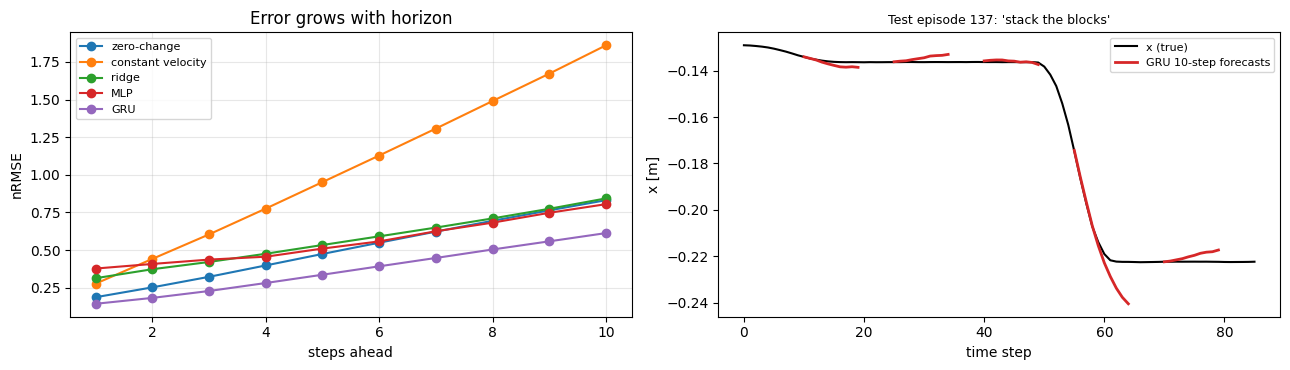

In [7]:
def hand_error_mm(P, Y):
    diff = (P[:, :, XYZ] - Y[:, :, XYZ]) * SD[XYZ]
    return np.linalg.norm(diff, axis=-1) * 1000     # (N, H) in mm

rows, per_h = [], {}
for name, predict in PREDICTORS.items():
    P = predict(Xte)
    err = np.sqrt(((P - Yte) ** 2).mean(axis=(0, 2)))      # per horizon
    mm = hand_error_mm(P, Yte)
    per_h[name] = err
    rows.append({"model": name, "nRMSE (all horizons)": float(np.sqrt(((P - Yte) ** 2).mean())),
                 "hand error 1 step [mm]": float(mm[:, 0].mean()), f"hand error {H} steps [mm]": float(mm[:, -1].mean())})
forecast_table = pd.DataFrame(rows).set_index("model")
display(forecast_table)
forecast_table.to_csv(os.path.join(RESULTS_DIR, "option1_forecasting.csv"))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for name, err in per_h.items():
    axes[0].plot(range(1, H + 1), err, marker="o", label=name)
axes[0].set_xlabel("steps ahead"); axes[0].set_ylabel("nRMSE"); axes[0].set_title("Error grows with horizon")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# example: GRU forecasts of the hand position along one test episode
i = TEST[0]; z = z_eps[i]
axes[1].plot(episodes[i][:, XYZ[0]], color="k", lw=1.5, label="x (true)")
for t in range(K, len(z) - H, 15):
    P = PREDICTORS["GRU"](z[None, t - K:t].astype(np.float32))[0]
    pred_x = (z[t - 1, XYZ[0]] + P[:, XYZ[0]]) * SD[XYZ[0]] + MU[XYZ[0]]
    axes[1].plot(range(t, t + H), pred_x, color="C3", lw=2)
axes[1].plot([], [], color="C3", lw=2, label="GRU 10-step forecasts")
axes[1].set_xlabel("time step"); axes[1].set_ylabel("x [m]"); axes[1].legend(fontsize=8)
axes[1].set_title(f"Test episode {i}: '{instructions[i]}'", fontsize=9)
plt.tight_layout(); plt.show()

## 5 — Inject synthetic anomalies into test episodes

The recordings contain no labelled failures, so — as is common in anomaly-detection research — known anomalies are **injected** into clean test episodes. This gives exact ground truth (where and when the anomaly is).

| Type | What it simulates | How it is injected (severity 1) |
|---|---|---|
| **jerk** | collision / bump | sudden offset of 5 × typical step change on 3 random values, for 5 steps |
| **freeze** | robot stalls / sensor stops updating | the state stays constant for 15 steps while the robot should be moving |
| **drift** | slipping object, calibration drift | offset growing linearly up to 10 × step change over 20 steps on 3 values |
| **noise** | sensor fault / vibration | Gaussian noise of 3 × step change on all values for 10 steps |

`severity` scales the size; Part 7 varies it.

In [8]:
ANOMALY_TYPES = ["jerk", "freeze", "drift", "noise"]
ANOMALY_LEN = {"jerk": 5, "freeze": 15, "drift": 20, "noise": 10}

def inject(z, kind, rng, severity=1.0):
    """Returns (corrupted copy of z, boolean label per step, start index)."""
    z = z.copy()
    T, L = len(z), ANOMALY_LEN[kind]
    lo, hi = K + 5, T - L - 5
    if kind == "freeze":   # start where the robot is actually moving
        speed = np.linalg.norm(np.diff(z[:, CONT_DIMS], axis=0), axis=1)
        cand = [t for t in range(lo, hi) if speed[t - 1] > np.median(speed)]
        t0 = int(rng.choice(cand)) if cand else int(rng.integers(lo, hi))
    else:
        t0 = int(rng.integers(lo, hi))
    dims = rng.choice(CONT_DIMS, size=3, replace=False)
    sign = rng.choice([-1.0, 1.0], size=3)
    if kind == "jerk":
        z[t0:t0 + L, dims] += severity * 5 * STEP_SD[dims] * sign
    elif kind == "freeze":
        z[t0:t0 + L] = z[t0 - 1]
    elif kind == "drift":
        z[t0:t0 + L, dims] += np.linspace(0, 1, L)[:, None] * severity * 10 * STEP_SD[dims] * sign
    elif kind == "noise":
        z[t0:t0 + L, CONT_DIMS] += rng.normal(0, 1, (L, len(CONT_DIMS))) * severity * 3 * STEP_SD[CONT_DIMS]
    label = np.zeros(T, bool)
    label[t0:t0 + L] = True
    return z, label, t0

def make_anomaly_set(severity=1.0, seed=SEED):
    rng = np.random.default_rng(seed)
    return {kind: [(i, *inject(z_eps[i], kind, rng, severity)) for i in TEST] for kind in ANOMALY_TYPES}

anomaly_set = make_anomaly_set()
print({k: len(v) for k, v in anomaly_set.items()}, "corrupted test episodes per type")

{'jerk': 66, 'freeze': 66, 'drift': 66, 'noise': 66} corrupted test episodes per type


## 6 — Detect anomalies from forecast errors

**Anomaly score at time *t*** = how surprising the observed state is, given what the model predicted:

- **1-step score:** compare the state at *t* with the prediction made one step earlier.
- **multi-step score:** compare the state at *t* with *all* predictions made 1…10 steps earlier (averaged). Slow anomalies such as freezes and drift build up over several steps, so looking further back should catch them better.

Errors are divided by the typical forecast error on clean validation episodes, then averaged over the continuous state values (the gripper is excluded: its open/close timing is legitimately hard to predict).

**Threshold:** the 99th percentile of scores on clean validation episodes (≈1 % false-alarm rate per step).

**Metrics:**
- **ROC-AUC** (step level): 1.0 = perfect separation of anomalous and normal steps, 0.5 = random.
- **Detection rate:** share of injected anomalies where the score crosses the threshold during the anomaly (+3 steps grace).
- **Delay:** steps from the anomaly start to the first threshold crossing.
- **False-alarm episodes:** share of *clean* test episodes where the threshold is crossed anywhere.

In [9]:
def residual_sd(predict):
    """Typical forecast error per (horizon, dim) on clean validation windows."""
    return np.maximum((predict(Xva) - Yva).std(0), 1e-3)

RES_SD = {name: residual_sd(p) for name, p in PREDICTORS.items()}

def anomaly_scores(z, name):
    """Returns (1-step score, multi-step score), each of length len(z) (NaN where undefined)."""
    predict, rsd = PREDICTORS[name], RES_SD[name]
    T = len(z)
    W = sliding_window_view(z, K, axis=0).transpose(0, 2, 1)[:T - K]    # window i ends at step K+i-1
    P = predict(W.astype(np.float32))
    acc, cnt = np.zeros(T), np.zeros(T)
    one = np.full(T, np.nan)
    idx = np.arange(len(P))
    for h in range(1, H + 1):
        tau = K + idx - 1 + h
        ok = tau < T
        r = (z[tau[ok]] - (z[K + idx[ok] - 1] + P[idx[ok], h - 1])) / rsd[h - 1]
        s = (r[:, CONT_DIMS] ** 2).mean(1)
        acc[tau[ok]] += s; cnt[tau[ok]] += 1
        if h == 1:
            one[tau[ok]] = s
    multi = np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan)
    smooth = lambda x: pd.Series(x).rolling(3, min_periods=1).mean().to_numpy()
    return smooth(one), smooth(multi)

DETECTORS = [(name, mode) for name in PREDICTORS for mode in ("1-step", "multi-step")]

def score_episode(z):
    out = {}
    for name in PREDICTORS:
        one, multi = anomaly_scores(z, name)
        out[(name, "1-step")], out[(name, "multi-step")] = one, multi
    return out

t0 = time.time()
clean_val = [score_episode(z_eps[i]) for i in VAL]
clean_test = [score_episode(z_eps[i]) for i in TEST]
THRESH = {d: np.nanpercentile(np.concatenate([s[d] for s in clean_val]), 99) for d in DETECTORS}
print(f"scored clean episodes in {time.time() - t0:.0f}s")

scored clean episodes in 0s


In [10]:
def roc_auc(scores, labels):
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty(len(scores)); ranks[order] = np.arange(1, len(scores) + 1)
    n_pos, n_neg = labels.sum(), (~labels).sum()
    return float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

def evaluate(anomaly_set, detectors=DETECTORS):
    corrupted = {kind: [(i, lab, t0, score_episode(zc)) for i, zc, lab, t0 in eps] for kind, eps in anomaly_set.items()}
    rows = []
    for d in detectors:
        false_alarm = np.mean([np.nanmax(s[d]) > THRESH[d] for s in clean_test])
        for kind, eps in corrupted.items():
            sc, lb, detected, delays = [], [], [], []
            for s in clean_test:                        # clean steps are negatives
                v = s[d]; m = ~np.isnan(v); sc.append(v[m]); lb.append(np.zeros(m.sum(), bool))
            for i, lab, t0, s in eps:
                v = s[d]; m = ~np.isnan(v); sc.append(v[m]); lb.append(lab[m])
                win = v[t0:t0 + ANOMALY_LEN[kind] + 3]
                hit = np.where(win > THRESH[d])[0]
                detected.append(len(hit) > 0)
                if len(hit):
                    delays.append(hit[0])
            rows.append({"predictor": d[0], "score": d[1], "anomaly": kind,
                         "ROC-AUC": roc_auc(np.concatenate(sc), np.concatenate(lb)),
                         "detection rate": float(np.mean(detected)),
                         "mean delay [steps]": float(np.mean(delays)) if delays else np.nan,
                         "false-alarm episodes": float(false_alarm)})
    return pd.DataFrame(rows), corrupted

t0 = time.time()
det_results, corrupted = evaluate(anomaly_set)
print(f"evaluated {len(DETECTORS)} detectors x {len(ANOMALY_TYPES)} anomaly types in {time.time() - t0:.0f}s")
det_results.to_csv(os.path.join(RESULTS_DIR, "option1_detection.csv"), index=False)

auc = det_results.pivot_table(index=["predictor", "score"], columns="anomaly", values="ROC-AUC")
auc["mean"] = auc.mean(1)
rate = det_results.pivot_table(index=["predictor", "score"], columns="anomaly", values="detection rate")
fa = det_results.groupby(["predictor", "score"])["false-alarm episodes"].first()
rate["false-alarm episodes"] = fa
print("ROC-AUC (higher is better):"); display(auc.sort_values("mean", ascending=False).round(3))
print("Detection rate at the 1 % threshold:"); display(rate.loc[auc.sort_values("mean", ascending=False).index].round(2))

evaluated 10 detectors x 4 anomaly types in 1s
ROC-AUC (higher is better):


anomaly                       drift  freeze   jerk  noise   mean
predictor         score                                         
GRU               multi-step  0.778   0.768  0.970  0.986  0.875
MLP               multi-step  0.762   0.718  0.966  0.984  0.857
GRU               1-step      0.863   0.506  0.972  0.994  0.834
MLP               1-step      0.860   0.469  0.968  0.992  0.822
ridge             multi-step  0.680   0.518  0.971  0.981  0.788
                  1-step      0.769   0.320  0.985  0.994  0.767
constant velocity multi-step  0.456   0.281  0.977  0.987  0.675
                  1-step      0.490   0.143  0.891  0.995  0.630
zero-change       multi-step  0.511   0.111  0.698  0.906  0.557
                  1-step      0.474   0.046  0.721  0.985  0.556

Detection rate at the 1 % threshold:


anomaly                       drift  freeze  jerk  noise  false-alarm episodes
predictor         score                                                       
GRU               multi-step   1.00    0.94  0.95   1.00                  0.15
MLP               multi-step   1.00    0.92  0.88   1.00                  0.09
GRU               1-step       1.00    1.00  1.00   1.00                  0.21
MLP               1-step       1.00    1.00  1.00   1.00                  0.06
ridge             multi-step   1.00    0.98  1.00   1.00                  0.27
                  1-step       1.00    1.00  1.00   1.00                  0.44
constant velocity multi-step   1.00    0.94  1.00   1.00                  0.29
                  1-step       1.00    1.00  1.00   1.00                  0.39
zero-change       multi-step   0.12    0.50  0.03   0.35                  0.24
                  1-step       1.00    0.79  0.08   1.00                  0.30

Best detector: ('GRU', 'multi-step')


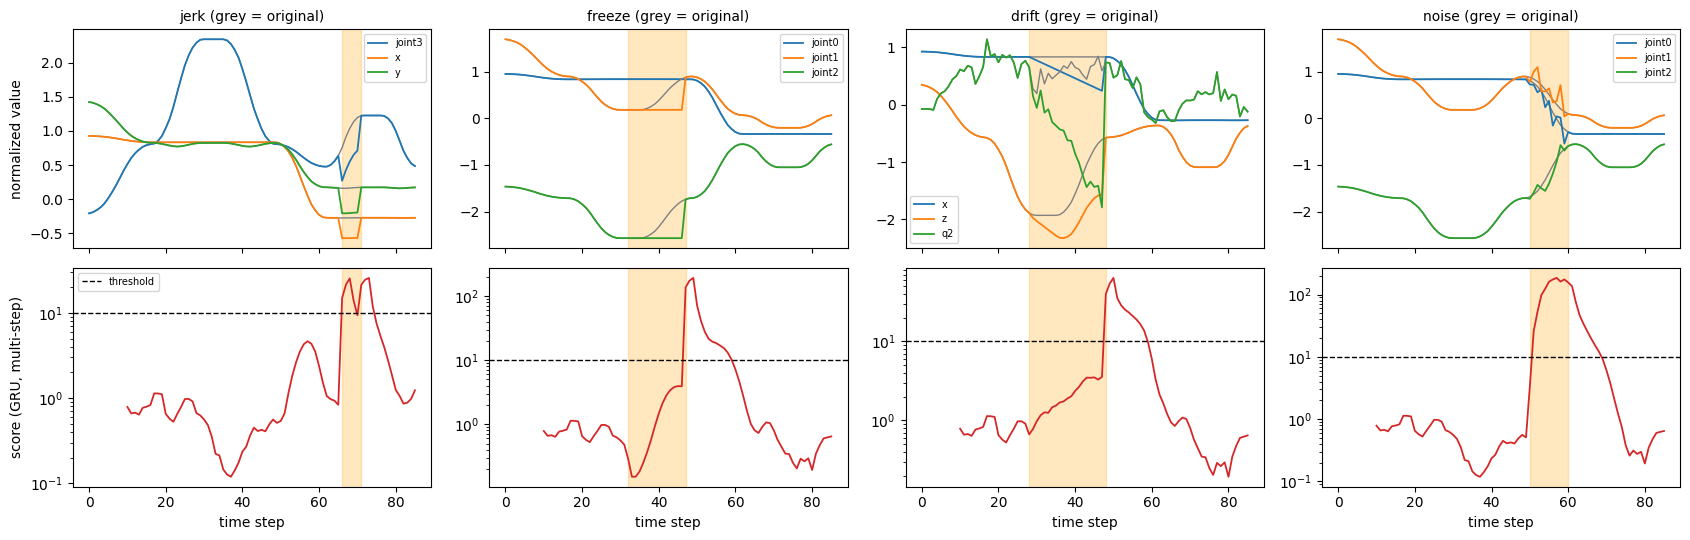

In [11]:
# One example per anomaly type: corrupted signal and the best detector's score
best = auc["mean"].idxmax()
print("Best detector:", best)
fig, axes = plt.subplots(2, 4, figsize=(17, 5.5), sharex="col")
for col, kind in enumerate(ANOMALY_TYPES):
    i, lab, t0, s = corrupted[kind][0]
    zc = anomaly_set[kind][0][1]
    dims_changed = np.where(np.abs(zc - z_eps[i]).max(0) > 1e-9)[0][:3]
    for d in dims_changed:
        axes[0, col].plot(z_eps[i][:, d], color="grey", lw=1)
        axes[0, col].plot(zc[:, d], lw=1.3, label=NAMES[d])
    axes[1, col].plot(s[best], color="C3", lw=1.3)
    axes[1, col].axhline(THRESH[best], color="k", ls="--", lw=1, label="threshold")
    for ax in axes[:, col]:
        ax.axvspan(t0, t0 + ANOMALY_LEN[kind], color="orange", alpha=0.25)
    axes[0, col].set_title(f"{kind} (grey = original)", fontsize=10); axes[0, col].legend(fontsize=7)
    axes[1, col].set_yscale("log"); axes[1, col].set_xlabel("time step")
axes[0, 0].set_ylabel("normalized value"); axes[1, 0].set_ylabel(f"score ({best[0]}, {best[1]})")
axes[1, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 7 — Sensitivity: how small an anomaly can be detected?

The injected anomalies are repeated at severities from 0.25× to 2× for the best learned detector and the constant-velocity baseline. The point where the curve rises is the **smallest detectable anomaly** — a clear, thesis-ready result.

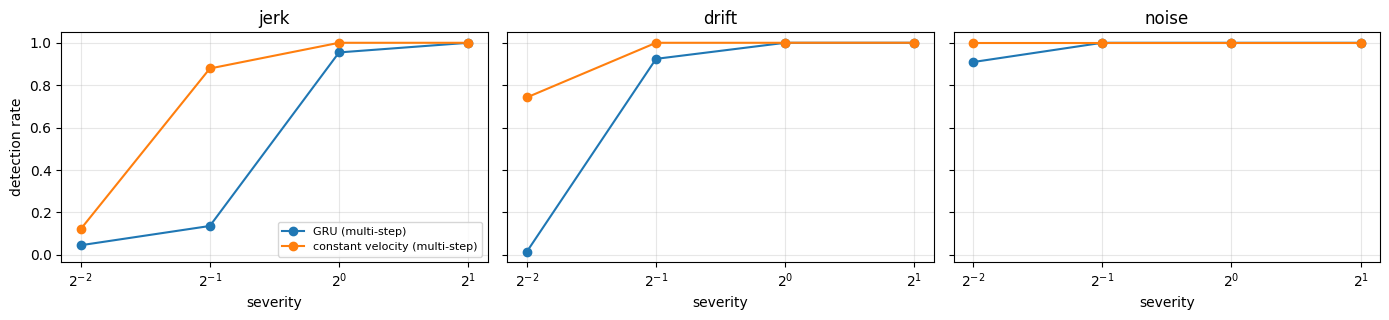

In [12]:
SEVERITIES = [0.25, 0.5, 1.0, 2.0]
learned = [d for d in auc.sort_values("mean", ascending=False).index if d[0] in ("MLP", "GRU", "ridge")][0]
baseline = ("constant velocity", "multi-step")
compare = [learned, baseline]

sweep = []
for sev in SEVERITIES:
    res, _ = evaluate(make_anomaly_set(sev, seed=SEED + 1), detectors=compare)
    res["severity"] = sev
    sweep.append(res)
sweep = pd.concat(sweep)
sweep.to_csv(os.path.join(RESULTS_DIR, "option1_severity_sweep.csv"), index=False)

kinds = [k for k in ANOMALY_TYPES if k != "freeze"]   # freeze has no size parameter
fig, axes = plt.subplots(1, len(kinds), figsize=(14, 3.3), sharey=True)
for ax, kind in zip(axes, kinds):
    for d in compare:
        sel = sweep[(sweep.anomaly == kind) & (sweep.predictor == d[0]) & (sweep.score == d[1])]
        ax.plot(sel.severity, sel["detection rate"], marker="o", label=f"{d[0]} ({d[1]})")
    ax.set_xscale("log", base=2); ax.set_title(kind); ax.set_xlabel("severity"); ax.grid(alpha=0.3)
axes[0].set_ylabel("detection rate"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 — Are there real anomalies in the recordings?

The best detector is run over **all** episodes (no injection). Episodes with the highest peak score are the most unusual motions in the dataset — e.g. hesitations, corrections by the operator, or recording glitches. Inspecting them (and their videos) could provide **real, hand-labelled anomalies** for the thesis.

Note: training episodes were seen by the model, so their scores are slightly optimistic; the ranking is still informative.

,episode,split,instruction,file,peak score,peak at step,length,steps above threshold
0,293,test,stack red and yellow blocks,stack_red_and_yellow_blocks_20250707_102443_ED...,1315.143,74,129,66
1,18,val,stack the cups,stack_the_cups_20250731_142458.npz,27.997,125,153,34
2,36,test,pick up the blue block and drop it in the box,pick_up_the_blue_block_and_drop_it_in_the_box_...,26.365,59,90,9
3,89,test,stack the blocks,stack_the_blocks_20250813_132843.npz,20.566,10,82,2
4,234,val,stack the blocks,stack_the_blocks_20250730_121806_EDITED.npz,20.098,10,93,3
5,436,test,stack the cups,stack_the_cups_20250728_123317_EDITED.npz,19.049,11,152,7
6,205,val,pick and place the yellow block in the box,pick_and_place_the_yellow_block_in_the_box_202...,17.946,62,110,7
7,44,test,drop yellow block into the box,drop_yellow_block_into_the_box_20250721_123725...,16.192,56,115,7
8,307,train,stack the cups,stack_the_cups_20250728_102011_EDITED.npz,15.045,10,180,2
9,204,val,stack the cups,stack_the_cups_20250724_150730_EDITED.npz,14.279,86,141,9


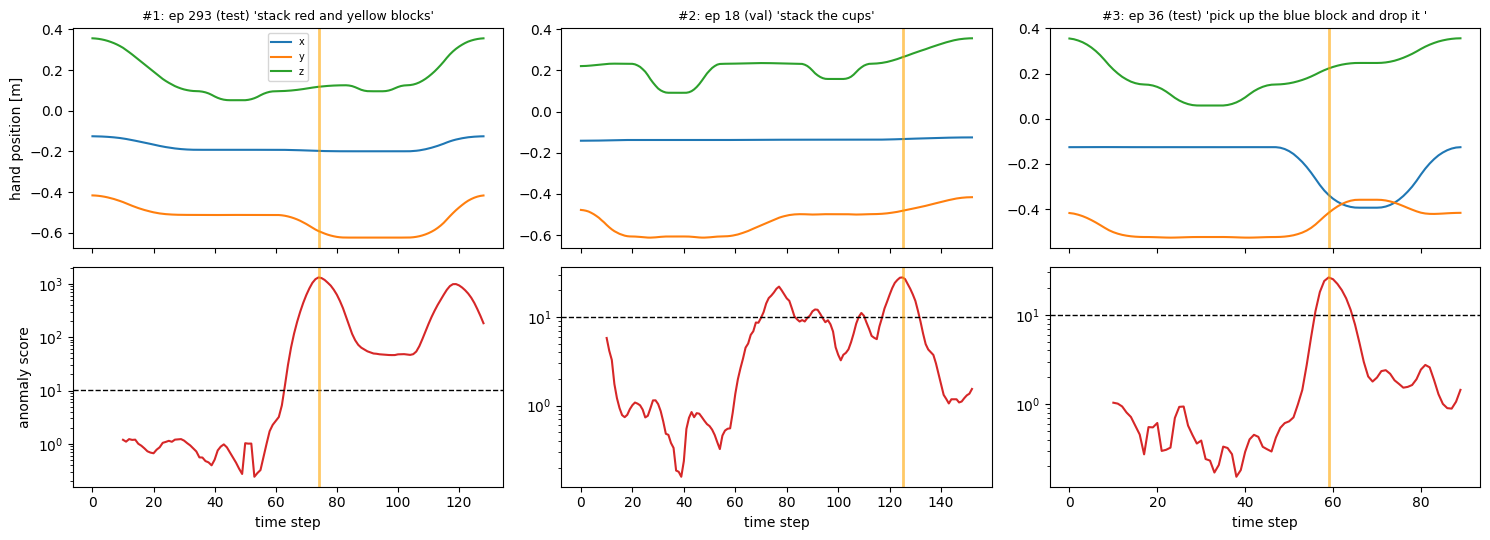

In [13]:
split_of = {int(i): "train" for i in TRAIN} | {int(i): "val" for i in VAL} | {int(i): "test" for i in TEST}
real = []
for i, z in enumerate(z_eps):
    one, multi = anomaly_scores(z, best[0])
    s = multi if best[1] == "multi-step" else one
    t_peak = int(np.nanargmax(s))
    real.append({"episode": i, "split": split_of[i], "instruction": instructions[i], "file": file_names[i],
                 "peak score": float(np.nanmax(s)), "peak at step": t_peak, "length": len(z),
                 "steps above threshold": int(np.nansum(s > THRESH[best]))})
real = pd.DataFrame(real).sort_values("peak score", ascending=False).reset_index(drop=True)
real.to_csv(os.path.join(RESULTS_DIR, "option1_real_episode_ranking.csv"), index=False)
display(real.head(10))

fig, axes = plt.subplots(2, 3, figsize=(15, 5.5), sharex="col")
for col in range(3):
    r = real.iloc[col]; i = int(r.episode)
    one, multi = anomaly_scores(z_eps[i], best[0])
    s = multi if best[1] == "multi-step" else one
    for d in XYZ:
        axes[0, col].plot(episodes[i][:, d], label=NAMES[d])
    axes[1, col].plot(s, color="C3"); axes[1, col].axhline(THRESH[best], color="k", ls="--", lw=1)
    for ax in axes[:, col]:
        ax.axvline(r["peak at step"], color="orange", lw=2, alpha=0.6)
    axes[0, col].set_title(f"#{col + 1}: ep {i} ({r.split}) '{r.instruction[:35]}'", fontsize=9)
    axes[1, col].set_yscale("log"); axes[1, col].set_xlabel("time step")
axes[0, 0].legend(fontsize=7); axes[0, 0].set_ylabel("hand position [m]"); axes[1, 0].set_ylabel("anomaly score")
plt.tight_layout(); plt.show()

## 9 — Summary

In [14]:
best_fc = forecast_table["nRMSE (all horizons)"].idxmin()
b = det_results[(det_results.predictor == best[0]) & (det_results.score == best[1])].set_index("anomaly")
cv = det_results[(det_results.predictor == "constant velocity") & (det_results.score == "multi-step")].set_index("anomaly")
print(f"""
DATA        {len(episodes)} episodes, {offsets[-1]} steps, {D} state values; {flips} quaternion sign flips repaired.
FORECASTING best model: {best_fc}
            hand-position error: {forecast_table.loc[best_fc, 'hand error 1 step [mm]']:.1f} mm (1 step), {forecast_table.loc[best_fc, f'hand error {H} steps [mm]']:.1f} mm ({H} steps)
            vs zero-change: {forecast_table.loc['zero-change', f'hand error {H} steps [mm]']:.1f} mm, constant velocity: {forecast_table.loc['constant velocity', f'hand error {H} steps [mm]']:.1f} mm ({H} steps)
DETECTION   best detector: {best[0]} ({best[1]} score), false-alarm episodes {b['false-alarm episodes'].iloc[0]:.0%}
""")
summary = pd.DataFrame({"ROC-AUC (best)": b["ROC-AUC"], "ROC-AUC (const. velocity)": cv["ROC-AUC"],
                        "detection rate (best)": b["detection rate"], "detection rate (const. velocity)": cv["detection rate"],
                        "mean delay [steps]": b["mean delay [steps]"]})
display(summary.round(3))


DATA        443 episodes, 57742 steps, 14 state values; 359 quaternion sign flips repaired.
FORECASTING best model: GRU
            hand-position error: 1.1 mm (1 step), 17.6 mm (10 steps)
            vs zero-change: 68.4 mm, constant velocity: 61.7 mm (10 steps)
DETECTION   best detector: GRU (multi-step score), false-alarm episodes 15%



,ROC-AUC (best),ROC-AUC (const. velocity),detection rate (best),detection rate (const. velocity),mean delay [steps]
anomaly,,,,,
jerk,0.970,0.977,0.955,1.000,0.492
freeze,0.768,0.281,0.939,0.939,12.387
drift,0.778,0.456,1.000,1.000,19.682
noise,0.986,0.987,1.000,1.000,0.136


### From this notebook to a master thesis

**Title idea:** *Learning-Based Anomaly Detection for Robot Manipulation via Motion Forecasting on Real UR5e Demonstrations*

**Suggested chapters / experiments:**
1. **Data & preprocessing** — the dataset, the quaternion sign-flip problem (and its effect on detection: try running Part 6 without the fix).
2. **Forecasting** — compare the baselines, ridge, MLP, GRU, plus one stronger model (Transformer or temporal CNN). Ablate the window length `K` and the horizon `H`.
3. **Action-conditioned forecasting** — the dataset also records the *commanded* actions. Feeding past (and current) commands to the model lets it tell "the robot was told to stop" from "the robot got stuck", which should reduce false alarms. This is a natural core contribution.
4. **Anomaly detection** — the synthetic benchmark from Part 5–7; add probabilistic forecasting (predict mean *and* variance, score with negative log-likelihood) and compare with a reconstruction-based detector (LSTM autoencoder) and a classic one (Isolation Forest on windows).
5. **Real anomalies** — manually inspect the top-ranked episodes from Part 8 (with their camera frames) and label them; report precision of the detector on real data.
6. **Discussion** — which anomaly types are easy or hard, how early they are detected, limits of synthetic anomalies.

**Everything above runs from the 5 MB `processed/robot_motion.npz` file** — no GPU and no robot needed.